In [3]:
import numpy as np
import pandas as pd
import random
import imgaug
from keras import utils
from time import time
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
!pip install imgaug

In [23]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout
from keras.utils import to_categorical

In [4]:
from PIL import Image
import os

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
train_dataset = pd.read_csv('/content/drive/MyDrive/Project/Train.csv')

In [7]:
train_dataset.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [8]:
test_dataset = pd.read_csv('/content/drive/MyDrive/Project/archive/Test.csv')

In [9]:
test_dataset.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


In [10]:
data = []
labels = []

classes = 43

cur_path = os.getcwd()
cur_path

'/content'

In [11]:
new_path = '/content/drive/MyDrive/Project'
os.chdir(new_path)

# Verify the change
cur_path = os.getcwd()
print(f"New working directory: {cur_path}")

New working directory: /content/drive/MyDrive/Project


In [12]:

# Assuming `classes` is the number of class folders
for i in range(classes):
    path = os.path.join('/content/drive/MyDrive/Project/Train', str(i))

    # Check if the directory exists
    if not os.path.isdir(path):
        print(f"Directory not found: {path}")
        continue

    try:
        images = os.listdir(path)
        print(f"Found {len(images)} images in directory: {path}")
    except Exception as e:
        print(f"Error accessing directory {path}: {e}")
        continue

    for a in images:
        try:
            image_path = os.path.join(path, a)
            # Open image
            image = Image.open(image_path).convert('RGB')  # Ensures 3 channels (RGB)
            # Resize image
            image = image.resize((30, 30))
            # Convert image to numpy array
            image = np.array(image)
            # Normalize image data (scaling pixel values to [0, 1])
            image = image / 255.0
            # Append image data and label
            data.append(image)
            labels.append(i)
        except Exception as e:
            print(f"Error loading image {a} from {path}: {e}")

# Convert lists to numpy arrays
data = np.array(data)
labels = np.array(labels)

print(f"Loaded {len(data)} images from {classes} classes.")


Found 210 images in directory: /content/drive/MyDrive/Project/Train/0
Found 2220 images in directory: /content/drive/MyDrive/Project/Train/1
Found 2250 images in directory: /content/drive/MyDrive/Project/Train/2
Found 1410 images in directory: /content/drive/MyDrive/Project/Train/3
Found 1980 images in directory: /content/drive/MyDrive/Project/Train/4
Found 1860 images in directory: /content/drive/MyDrive/Project/Train/5
Found 420 images in directory: /content/drive/MyDrive/Project/Train/6
Found 1440 images in directory: /content/drive/MyDrive/Project/Train/7
Found 1410 images in directory: /content/drive/MyDrive/Project/Train/8
Found 1470 images in directory: /content/drive/MyDrive/Project/Train/9
Found 2010 images in directory: /content/drive/MyDrive/Project/Train/10
Found 1320 images in directory: /content/drive/MyDrive/Project/Train/11
Found 2100 images in directory: /content/drive/MyDrive/Project/Train/12
Found 2160 images in directory: /content/drive/MyDrive/Project/Train/13
Foun

In [13]:
print(data.shape, labels.shape)

(39209, 30, 30, 3) (39209,)


In [14]:
def preview(images, labels):
    plt.figure(figsize=(16, 16))
    for c in range(len(np.unique(labels))):
        i = random.choice(np.where(labels == c)[0])
        plt.subplot(8, 8, c+1)
        plt.axis('off')
        plt.title('class: {}'.format(c))
        plt.imshow(images[i])

In [15]:
# Code from here
# https://medium.com/ai-in-plain-english/traffic-sign-recognition-problem-with-gtsrb-python-and-keras-21782b7b3520
def augment_imgs(imgs, p):
    """
    Performs a set of augmentations with with a probability p
    """
    from imgaug import augmenters as iaa
    augs =  iaa.SomeOf((2, 4),
          [
              iaa.Crop(px=(0, 4)), # crop images from each side by 0 to 4px (randomly chosen)
              iaa.Affine(scale={"x": (0.8, 1.2), "y": (0.8, 1.2)}),
              iaa.Affine(translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)}),
              iaa.Affine(rotate=(-45, 45)), # rotate by -45 to +45 degrees)
              iaa.Affine(shear=(-10, 10)) # shear by -10 to +10 degrees
          ])

    seq = iaa.Sequential([iaa.Sometimes(p, augs)])
    res = seq.augment_images(imgs)
    return res

def count_images_in_classes(lbls):
    dct = {}
    for i in lbls:
        if i in dct:
            dct[i] += 1
        else:
            dct[i] = 1
    return dct

In [16]:
def augmentation(imgs, lbls):
    classes = train_dataset.value_counts('ClassId').to_dict()
    for i in range(len(classes)):
        if (classes[i] < 210):
            # Number of samples to be added
            add_num = 210 - classes[i]
            imgs_for_augm = []
            lbls_for_augm = []
            for j in range(add_num):
                im_index = random.choice(np.where(lbls == i)[0])
                imgs_for_augm.append(imgs[im_index])
                lbls_for_augm.append(lbls[im_index])
            augmented_class = augment_imgs(imgs_for_augm, 1)
            augmented_class_np = np.array(augmented_class)
            augmented_lbls_np = np.array(lbls_for_augm)
            imgs = np.concatenate((imgs, augmented_class_np), axis=0)
            lbls = np.concatenate((lbls, augmented_lbls_np), axis=0)
    return (imgs, lbls)

In [17]:
data, labels = augmentation(data, labels)

In [18]:
print(data.shape)
print(labels.shape)

(39209, 30, 30, 3)
(39209,)


Loading:  0.6583373546600342


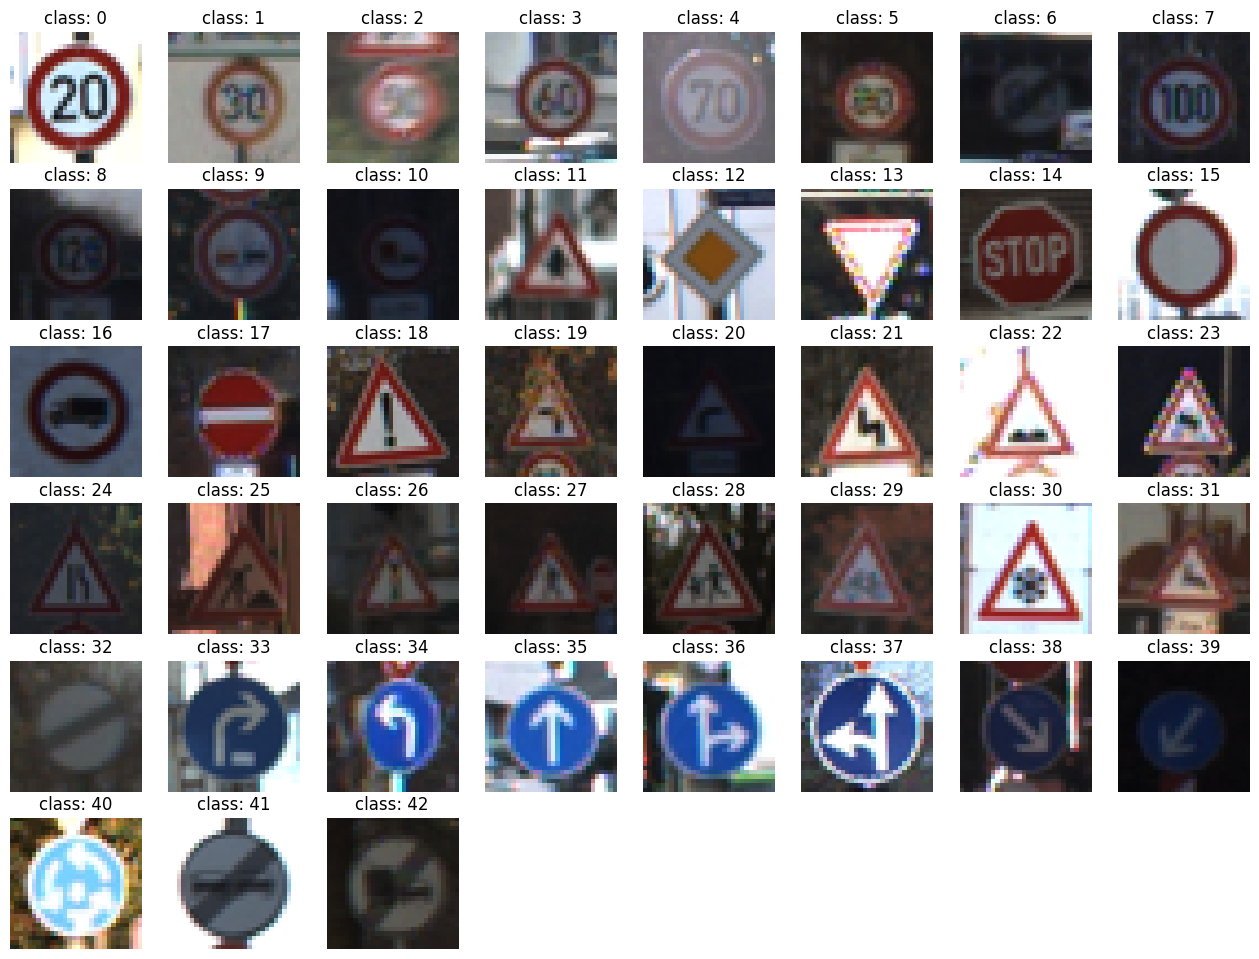

In [19]:
start = time()
from skimage.color import rgb2gray

preview(data, labels)
print('Loading: ', time() - start)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

In [25]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(31367, 30, 30, 3) (7842, 30, 30, 3) (31367,) (7842,)


In [26]:
y_train = to_categorical(y_train, 43)#One-hot encoding helps in treating each class independently, making the learning process more balanced.
y_test = to_categorical(y_test, 43)

In [27]:
# Creating a Sequential() model by passing a list of layer instances as present in the further steps.
model = Sequential()

# We need to implement a convo layer to extract the features of the images.
# Also, here we are utilising the ReLU activation layer to convert all negative values to zero.
# Convolution Layer 1
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=X_train.shape[1:]))
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu'))

# After the construction of the above convolution layer. Now we need to apply max pooling
# This is required so as to reduce the spatial volume of the image before feeding the above convo layer to the Fully Connected layer.
# Pooling Layer 1
model.add(MaxPool2D(pool_size=(2,2)))

# The dropout layer prevents overfitting and removes some of the neurons while the model is being trained. Hence we are required to implement this layer in our CNN model architechture.
# We are choosing the dropout rate as 0.25 because it helps in gradually increasing the accuracy and reducing the loss.
# Dropout layer 1
model.add(Dropout(rate=0.25))

# Convolution Layer 2
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))

# Pooling Layer 2
model.add(MaxPool2D(pool_size=(2,2)))

# Dropout Layer 2
model.add(Dropout(rate=0.25))

# The next step is to implement a Flatten layer to transform a two-dimensional matrix of features into a vector that can be fed into a fully connected neural network classifier.
model.add(Flatten())

# After the implementation of the above steps we are required to create a Fully Connected Layer (Dense Layer).
# Here the results of the above 2 convolutional layers are fed through to generate a prediction.
# To this dense layer we need to again add a dropout layer.
model.add(Dense(256, activation='relu'))
model.add(Dropout(rate=0.25))

# As the problem statement is a mutli classification problem we are required to use softmax in the last layer of the CNN.
model.add(Dense(43, activation='softmax'))

# We need to compile the model with Adam Optimizer as it performs well and categorical_crossentropy because our dataset has multiple classes to be classified.
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [17]:
epochs = 15
history = model.fit(X_train, y_train, batch_size=64, epochs=epochs, validation_data=(X_test, y_test))

Epoch 1/15
491/491 [==============================] - 15s 28ms/step - loss: 1.3249 - accuracy: 0.6340 - val_loss: 0.1554 - val_accuracy: 0.9582
Epoch 2/15
491/491 [==============================] - 13s 26ms/step - loss: 0.2001 - accuracy: 0.9402 - val_loss: 0.0796 - val_accuracy: 0.9824
Epoch 3/15
491/491 [==============================] - 13s 26ms/step - loss: 0.1164 - accuracy: 0.9657 - val_loss: 0.0519 - val_accuracy: 0.9881
Epoch 4/15
491/491 [==============================] - 14s 28ms/step - loss: 0.0911 - accuracy: 0.9740 - val_loss: 0.0397 - val_accuracy: 0.9902
Epoch 5/15
491/491 [==============================] - 13s 27ms/step - loss: 0.0704 - accuracy: 0.9790 - val_loss: 0.0274 - val_accuracy: 0.9918
Epoch 6/15
491/491 [==============================] - 13s 27ms/step - loss: 0.0580 - accuracy: 0.9825 - val_loss: 0.0226 - val_accuracy: 0.9952
Epoch 7/15
491/491 [==============================] - 14s 28ms/step - loss: 0.0510 - accuracy: 0.9846 - val_loss: 0.0278 - val_accuracy:

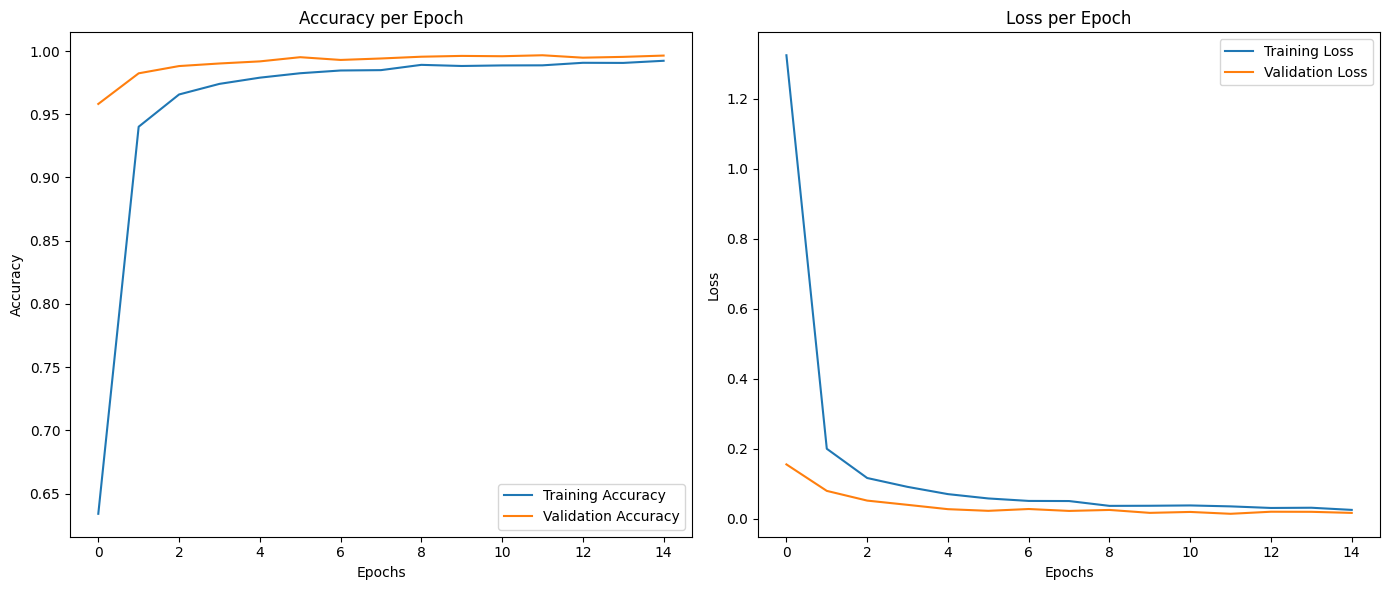

In [18]:
import matplotlib.pyplot as plt

# Create a figure and two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot for accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Accuracy per Epoch')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot for loss
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Loss per Epoch')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

# Display the plots
plt.tight_layout()
plt.show()


In [19]:
from sklearn.metrics import accuracy_score

In [27]:
y_test = pd.read_csv('Test.csv')
labels = y_test["ClassId"].values
imgs = y_test["Path"].values

data=[]

# Correct the paths
corrected_imgs = ['Test/' + img for img in imgs]

for img in corrected_imgs:
  if not os.path.exists(img):
      print(f"File not found: {image_path}. Stopping processing.")
      break  # Stop processing if the file does not exist
  image = Image.open(img)

  image = image.resize((30,30))
  data.append(np.array(image))

X_test=np.array(data)

# Predict the classes using the trained model
pred = model.predict(X_test)  # Get the predicted probabilities
pred_classes = np.argmax(pred, axis=1)  # Get the class with the highest probability

# Calculate and print the accuracy score
print(accuracy_score(labels[:len(pred_classes)], pred_classes))

File not found: /content/drive/MyDrive/Project/Train/42/00042_00004_00026.png. Stopping processing.
88/88 [==============================] - 0s 5ms/step
0.9705882352941176


In [28]:
model.save(r'/content/drive/MyDrive/Project/CNN_model_RTSR.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [29]:
import os
import csv

# Define your model metrics
model_name = 'CNN'

# Define the CSV file path
filename = '/content/drive/MyDrive/Project/model_accuracies.csv'

# Check if the file already exists
file_exists = os.path.isfile(filename)

# Open the file in append mode and write the metrics
with open(filename, mode='a', newline='') as file:
    writer = csv.writer(file)

    if not file_exists:
        # Write the header if the file doesn't exist yet
        writer.writerow(['Model', 'Test Accuracy', 'Test Loss'])

    # Write the model's metrics
    writer.writerow([model_name, history.history['val_accuracy'][-1], history.history['val_loss'][-1]])

print(f"Metrics saved to {filename}")

Metrics saved to /content/drive/MyDrive/Project/model_accuracies.csv
